# Greedy 2-factor approximation algorithm for the Vertex Cover problem

## Importing necessary libraries

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import pandas as pd
import random

## Dictionary of graphs loaded from edge list files where each key represents the filename, and each value is a NetworkX Graph object.
## The parameter nodetype=int ensures that all nodes are interpreted as integers.

In [5]:
graphs = {
    "n=10,m=10.txt": nx.read_edgelist("n=10,m=10.txt", nodetype=int),
    "n=10,m=20.txt": nx.read_edgelist("n=10,m=20.txt", nodetype=int),
    "n=10,m=30.txt": nx.read_edgelist("n=10,m=30.txt", nodetype=int),
    "n=10,m=40.txt": nx.read_edgelist("n=10,m=40.txt", nodetype=int),
}

## Visualization of each graph stored in the 'graphs' dictionary.

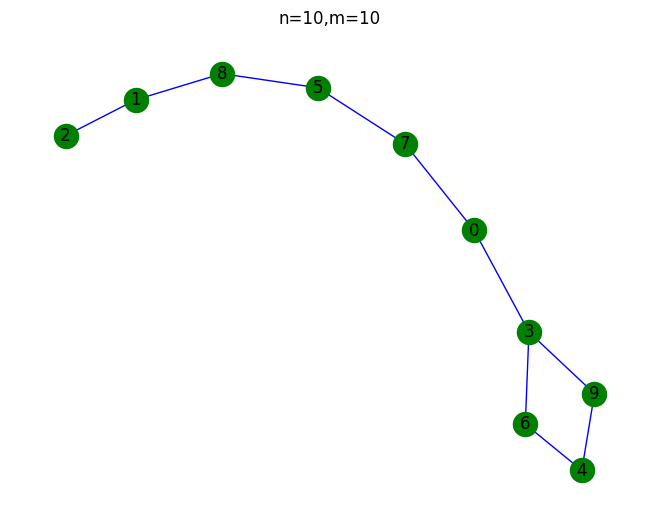

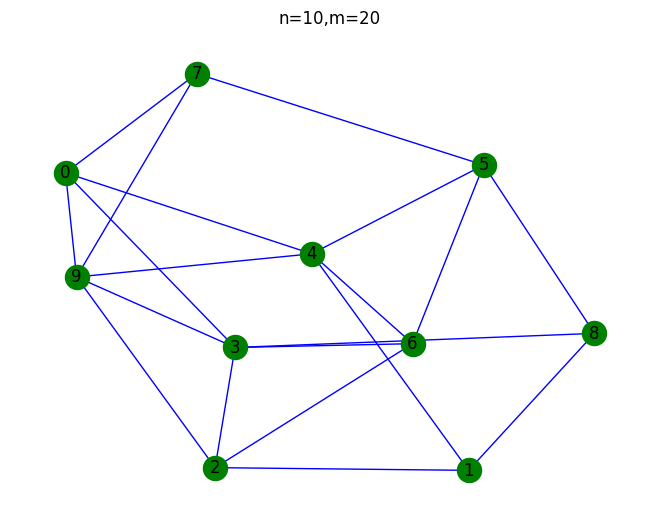

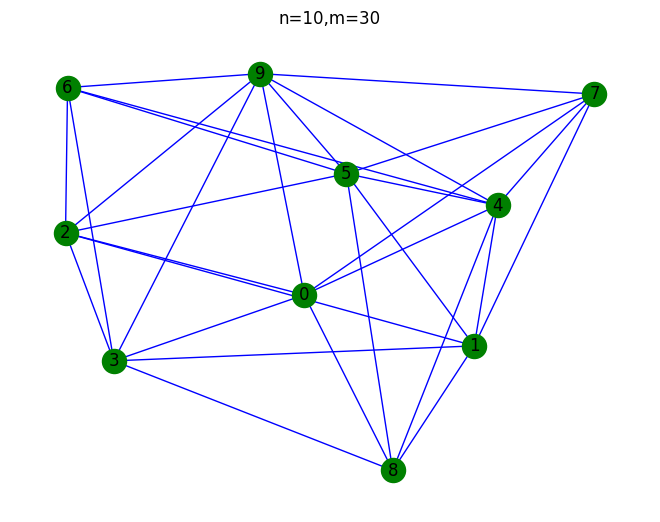

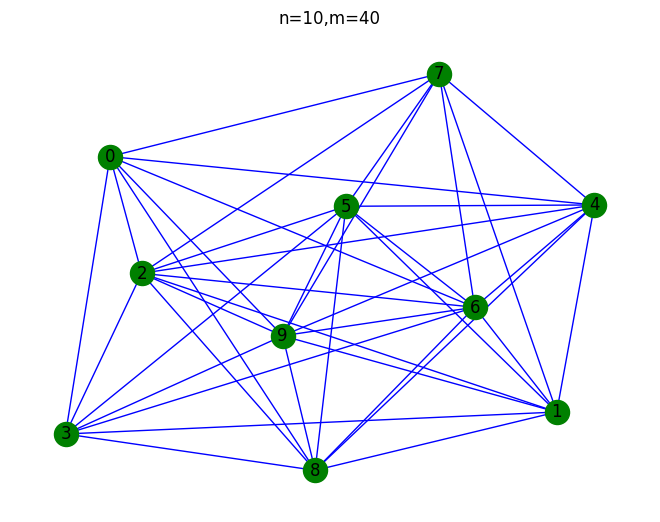

In [7]:
for i, (name, graph) in enumerate(graphs.items(), start=1):
    plt.figure(i)
    nx.draw(graph, pos=nx.spring_layout(graph, seed=5), with_labels=True, node_color='green', edge_color='blue')
    plt.title(name.replace(".txt",""))

## Vertex cover function where C is the set of vertex cover and M is the set of Maximal matching

In [9]:
def vertex_cover_2approx(G):
    C = set()
    M = set()
    edges = set(G.edges())

    while edges:
        (u, v) = random.choice(list(edges))
        C.add(u)
        C.add(v)
        M.add((u, v))
        edges = {e for e in edges if u not in e and v not in e}

    return C, M

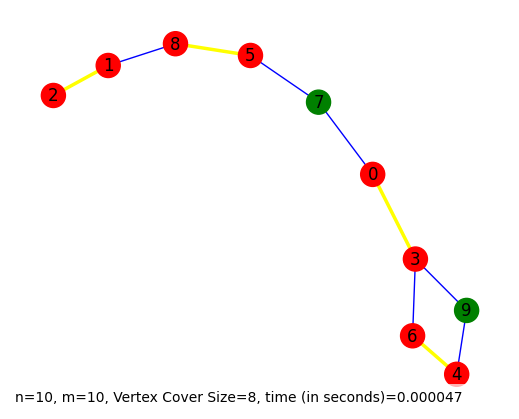

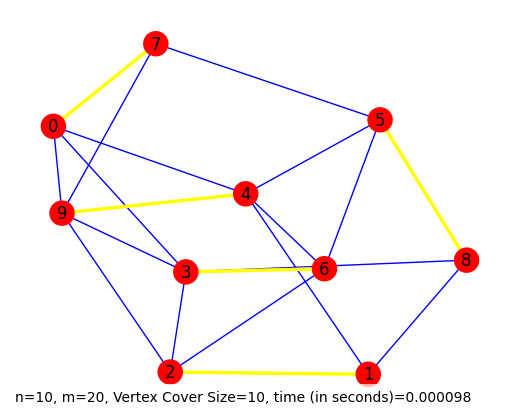

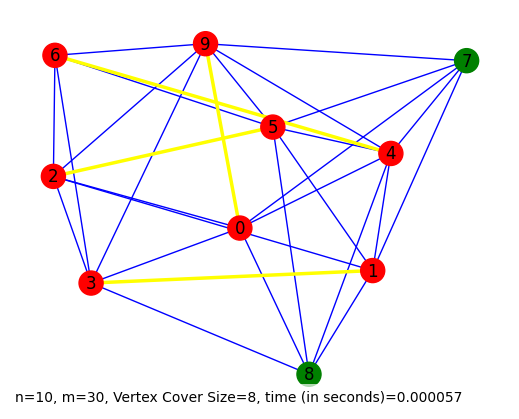

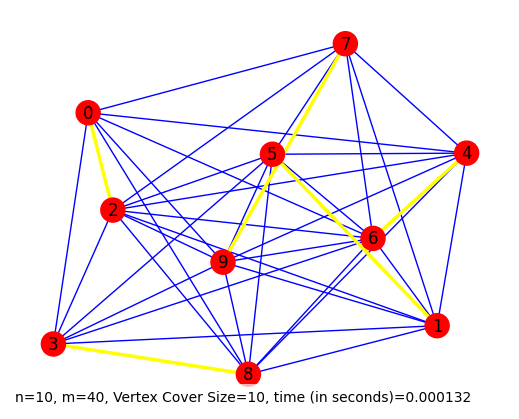

In [10]:
results = []

m = [10, 20, 30, 40]
for i, graph in enumerate(graphs.values(), start=1):
    # measuring time taken to find vertex cover for each graph
    start_time = time.perf_counter()
    vc, max_match = vertex_cover_2approx(graph)
    end_time = time.perf_counter()

    # Draw the full graph with colored nodes red for those in vertex cover and green for those not in vertex cover
    
    node_colors = ['red' if node in vc else 'green' for node in graph.nodes()]
    plt.figure(figsize=(5, 4))
   
    nx.draw(graph, pos=nx.spring_layout(graph, seed=5), with_labels=True, node_color=node_colors, edge_color="blue")
    nx.write_adjlist(graph, f"graph{i}out.txt")
    
    # Highlight matching edges in yellow (thicker for visibility)
    nx.draw_networkx_edges(
        graph,
        pos=nx.spring_layout(graph, seed=5),
        edgelist=max_match,
        edge_color="yellow",
        width=2.5
    )
    
    # annotation text box
    plt.text(0.01, 0.02,
             f"n=10, m={m[i-1]}, Vertex Cover Size={len(vc)}, time (in seconds)={(end_time - start_time):.6f}",
             transform=plt.gca().transAxes, fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # Save the visualization as an image file
    plt.savefig(f"n=10,m={m[i-1]}.png")

    # results
    results.append({
        "n": 10,
        "m": m[i-1],
        "greedy_vertex_cover_size": len(vc),
        "time (in seconds)": end_time - start_time
    })


## Loading data from brute force vertex cover solution

In [12]:
df_opt = pd.read_csv("vertex_cover_results.csv")
df_opt

,n,m,vertex cover size,time (in seconds)
0,10,10,5,0.000969
1,10,20,6,0.002573
2,10,30,7,0.004884
3,10,40,8,0.005507


In [13]:
# Create a new DataFrame to store and compare the approximation factor and time taken to find vertex cover
df = pd.DataFrame(results)
df['opt_vertex_cover_size'] = df_opt['vertex cover size']
df['opt_vertex_cover_time (in seconds)'] = df_opt['time (in seconds)']
df['approximation_factor'] = df['greedy_vertex_cover_size'] / df['opt_vertex_cover_size']
file_path = 'greedy_vertex_cover_results.csv'
df.to_csv(file_path, index=False)
df

,n,m,greedy_vertex_cover_size,time (in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor
0,10,10,8,0.000047,5,0.000969,1.600000
1,10,20,10,0.000098,6,0.002573,1.666667
2,10,30,8,0.000057,7,0.004884,1.142857
3,10,40,10,0.000132,8,0.005507,1.250000


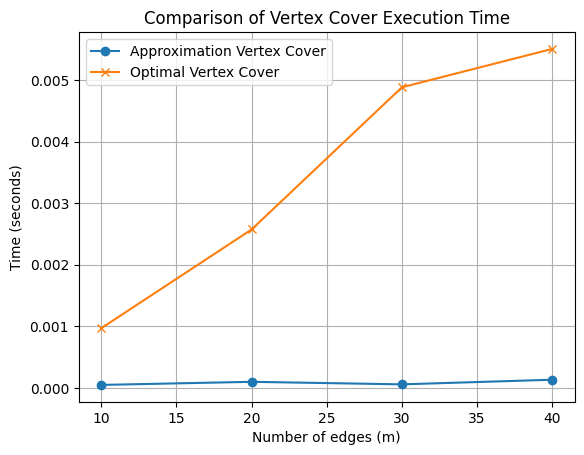

In [14]:
# Plot execution time of approximation vs optimal vertex cover algorithms
plt.plot(
    df['m'], 
    df['time (in seconds)'], 
    marker='o', 
    label='Approximation Vertex Cover'
)

plt.plot(
    df['m'], 
    df['opt_vertex_cover_time (in seconds)'], 
    marker='x', 
    label='Optimal Vertex Cover'
)

# Label axes
plt.xlabel("Number of edges (m)")         # x-axis: number of edges in the graph
plt.ylabel("Time (seconds)")              # y-axis: execution time in seconds
plt.title("Comparison of Vertex Cover Execution Time")
plt.grid(True)
plt.legend()
plt.show()